In [1]:
# imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from methods import COMMERCIAL_OPERATOR_LIST

## Detection Limit Plot

Aeromon detected all non-zero releases.
GSMA detected all non-zero releases.
SeekOps detected all non-zero releases.


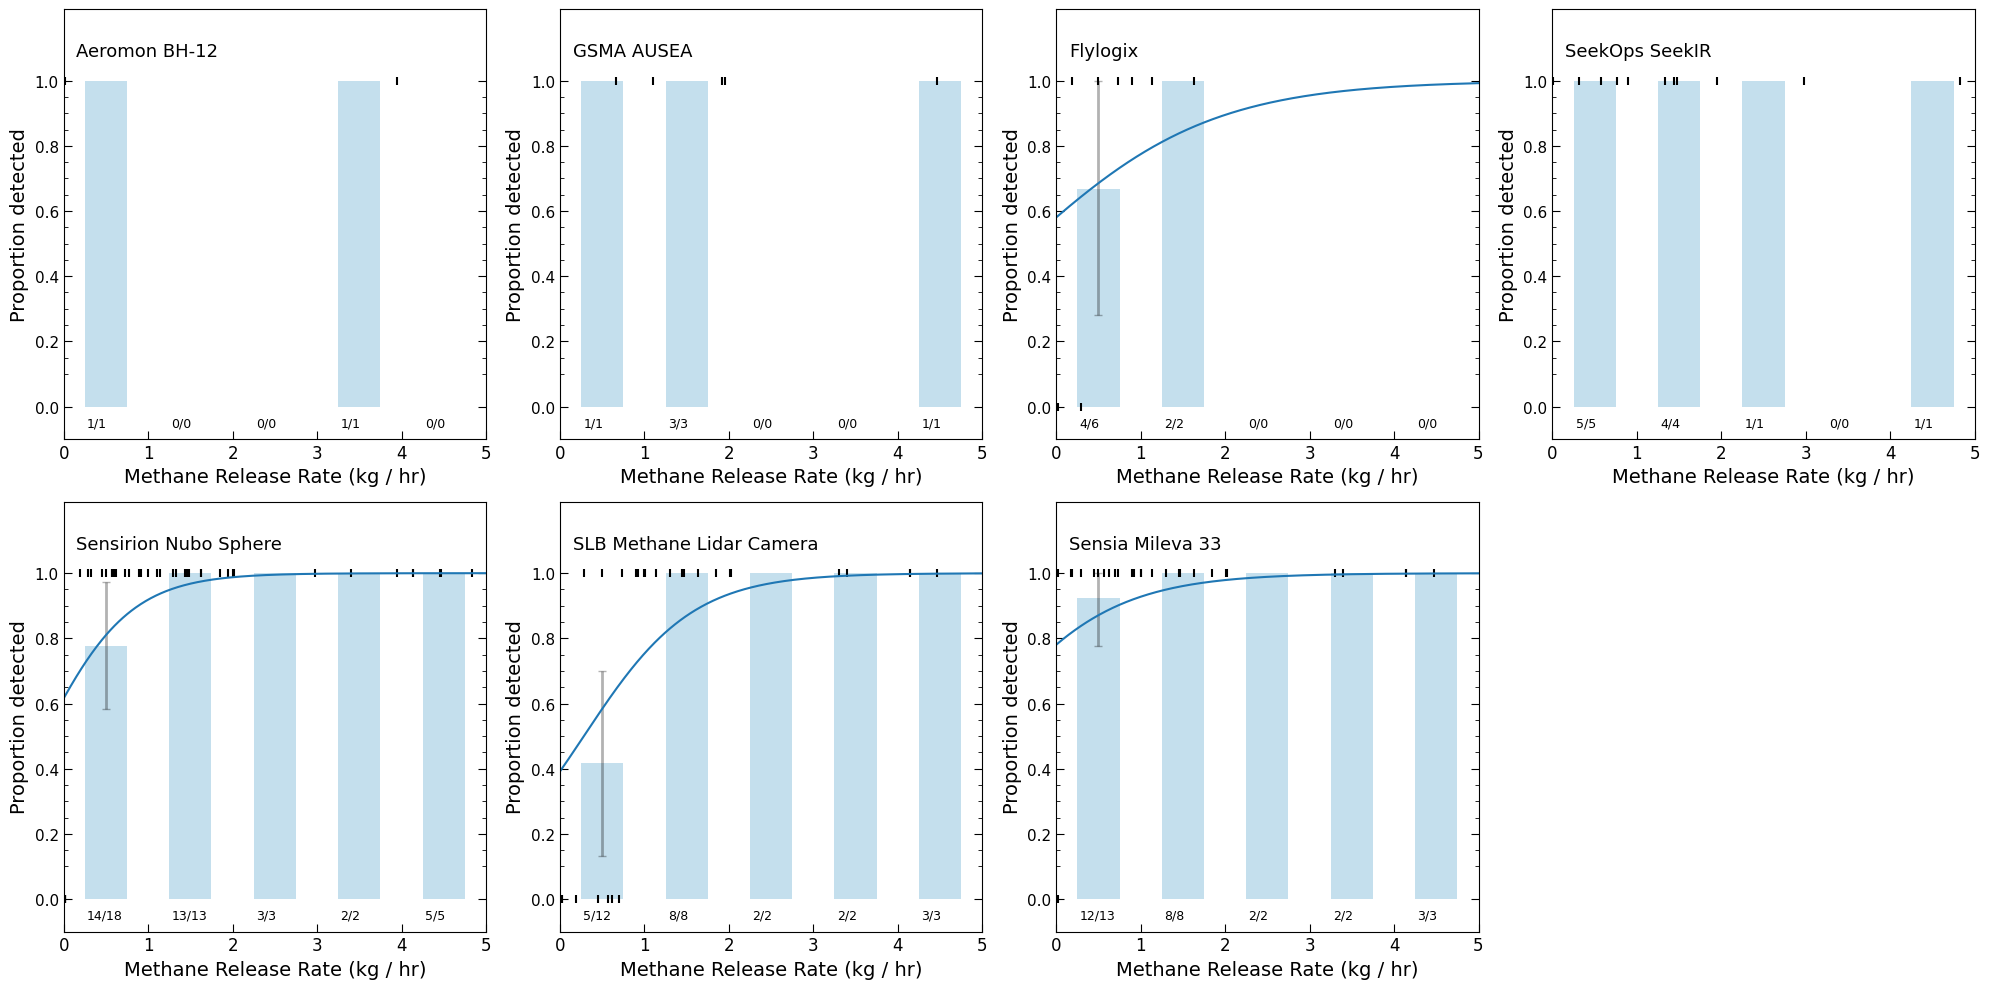

In [2]:
from plot_methods import plot_detection_limit, make_detection_limit_plot, plot_logistic_regression

fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
n_bins = 5
threshold = 5
ops = [op for op in COMMERCIAL_OPERATOR_LIST if op not in ['GHGSat', 'FAAM', 'EMPA']]

for i, operator in enumerate(ops):
    make_detection_limit_plot(ax=ax[i], operator=operator, n_bins=n_bins,threshold=threshold)
    try:
        plot_logistic_regression(ax=ax[i], threshold=threshold, operator=operator)
    except ValueError as e:
        if 'at least 2 classes' in str(e):
            print(f'{operator} detected all non-zero releases.')

for i in [7]:
    ax[i].axis('off');
plt.tight_layout()
# plt.savefig("report/plots/commercial_teams/commercial_ops_detection_limit_prob_under_5kgh.png")
plt.show()

## Histogram of release classification

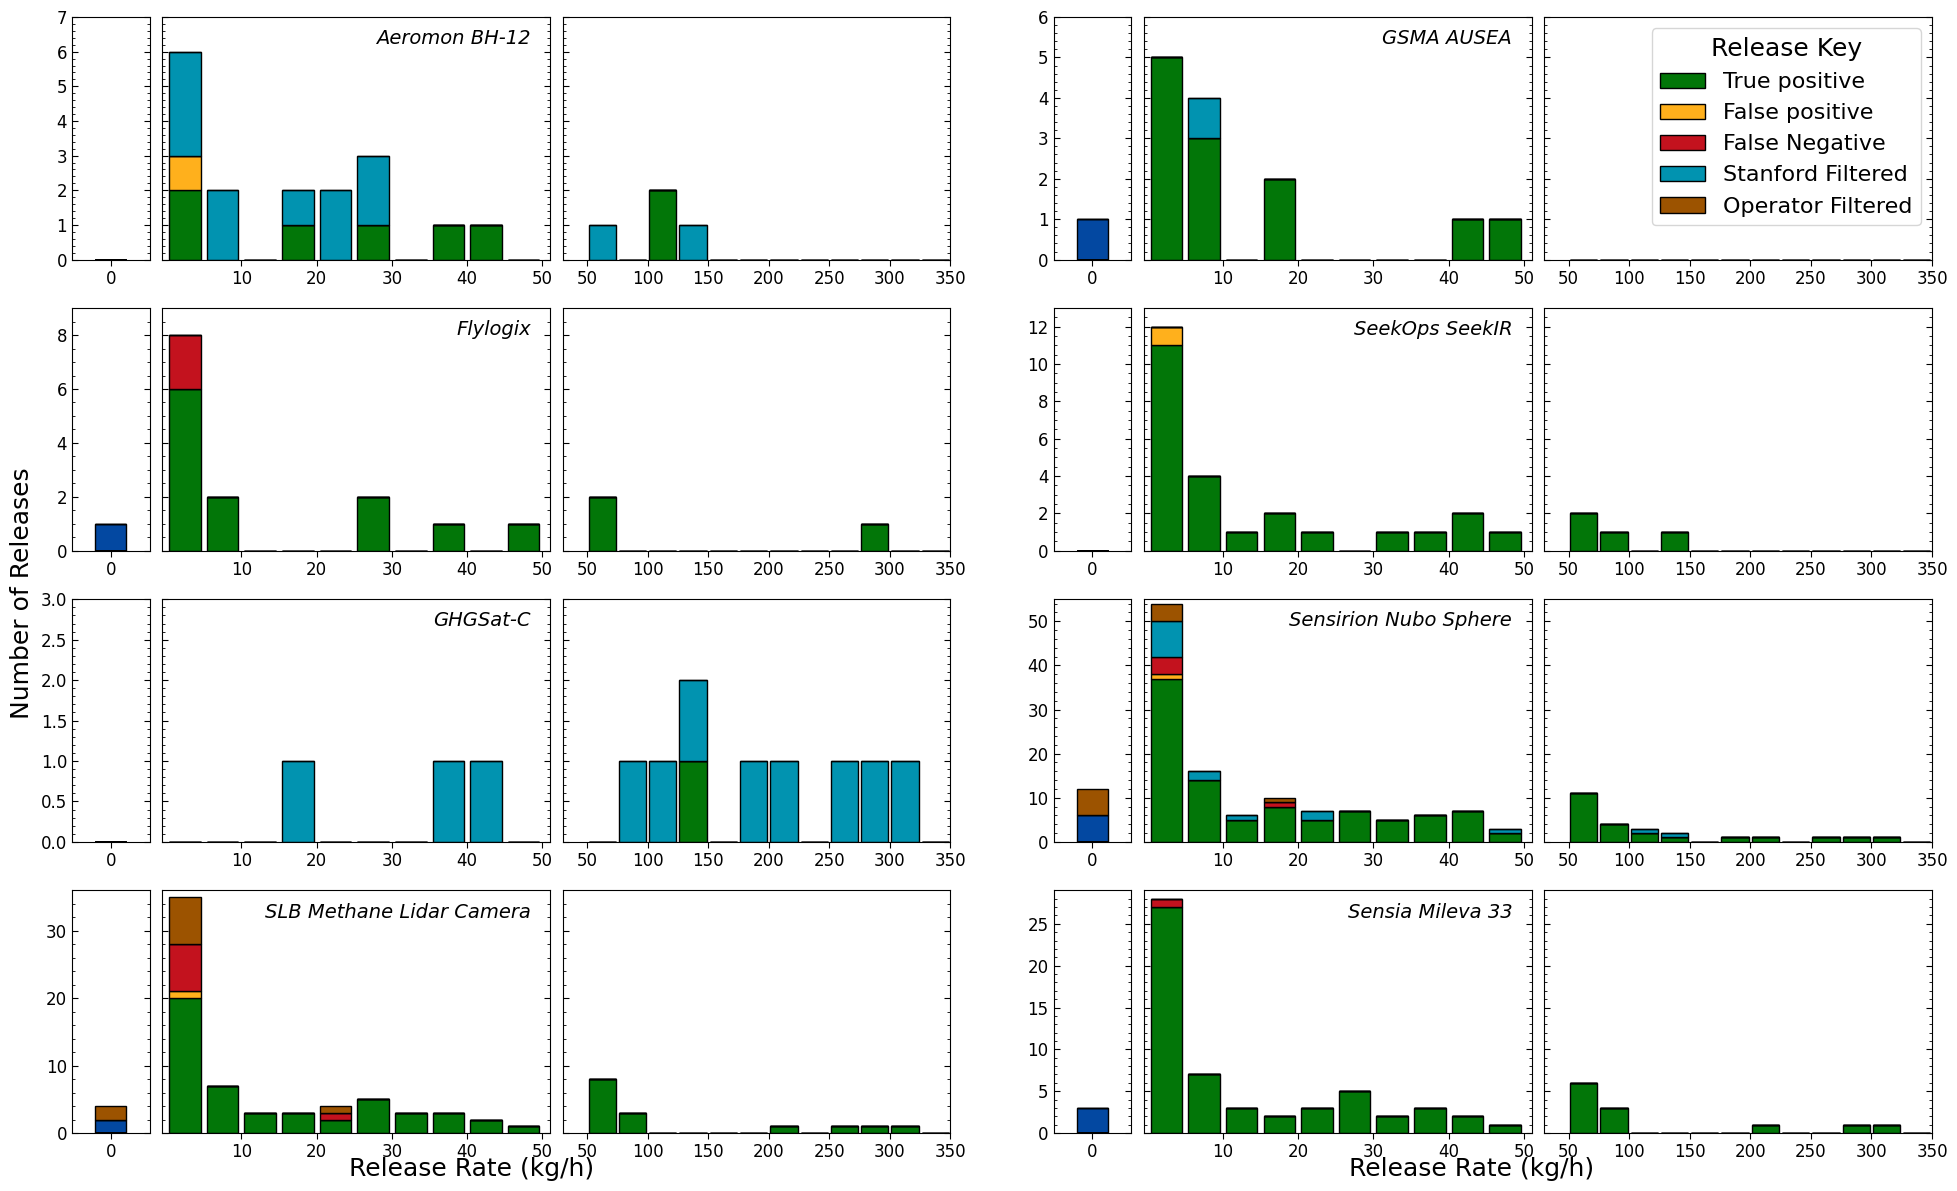

In [3]:
import matplotlib.pyplot as plt
import math
import numpy as np
from matplotlib.patches import Patch
from methods import OPERATOR_LIST
from plot_methods import make_releases_histogram, OPERATOR_PLOT_TITLES

def make_operator_histogram_plots(OPERATOR_LIST, fig, axes):

    k = 0
    for i, operator in enumerate(OPERATOR_LIST):
        if operator in OPERATOR_PLOT_TITLES.keys():
            title = OPERATOR_PLOT_TITLES[operator]
        else: 
            title = operator
        if i % 2 == 0:
            make_releases_histogram(operator, fig=fig, ax=[axes[k, 0], axes[k, 1], axes[k, 2]])
            axes[k, 3].axis('off')
            axes[k, 0].set_ylabel('')
            axes[k, 2].legend_.remove()
            
            # title text box
            axes[k, 1].text(0.95, 0.95, f"{title}",
                transform=axes[k, 1].transAxes, ha='right', va='top', fontsize=14, fontstyle='italic')
            
        else:
            make_releases_histogram(operator, fig=fig, ax=[axes[k, 4], axes[k, 5], axes[k, 6]])
            axes[k, 6].legend_.remove()
            axes[k, 4].set_ylabel('')
            # axes[k, 7].axis('off')

            # title text box
            axes[k, 5].text(0.95, 0.95, f"{title}",
                transform=axes[k, 5].transAxes, ha='right', va='top', fontsize=14, fontstyle='italic')
            k += 1
        
    plt.subplots_adjust(left=0.05,
                        bottom=0.05,
                        right=0.98,
                        top=0.98,
                        wspace=0.05,
                        hspace=0.2)

fig, axes = plt.subplots(4, 7, figsize=(20, 12), gridspec_kw={'width_ratios': [0.4, 2, 2, 0.4, 0.4, 2, 2]})
make_operator_histogram_plots(COMMERCIAL_OPERATOR_LIST, fig, axes)

# Common label for x-axis on all subplots
txt_x_label1 = fig.text(0.25, 0.01, 'Release Rate (kg/h)', ha='center', va='bottom', fontsize=18)
txt_x_label2 = fig.text(0.75, 0.01, 'Release Rate (kg/h)', ha='center', va='bottom', fontsize=18)

# Common label for y-axis on all subplots
txt_y_label = fig.text(0.025, 0.5, 'Number of Releases', ha='center', va='center', fontsize=18, rotation=90)


# set legend 
# handles, labels = axes[0, 2].get_legend_handles_labels()
# axes[0, 7].axis('on')
# axes[0, 7].set_xticks([])
# axes[0, 7].set_yticks([])
# for spine in axes[0, 7].spines.values():
#     spine.set_visible(False)
# axes[0, 7].legend(handles, labels, loc='upper left', fontsize=16, title='Release Key', title_fontsize=16)
axes[0, 6].legend(fontsize=16, title='Release Key', title_fontsize=18)

plt.savefig("report/plots/commercial_teams/commercial_ops_histograms_2_cols.png")


## Parity plots

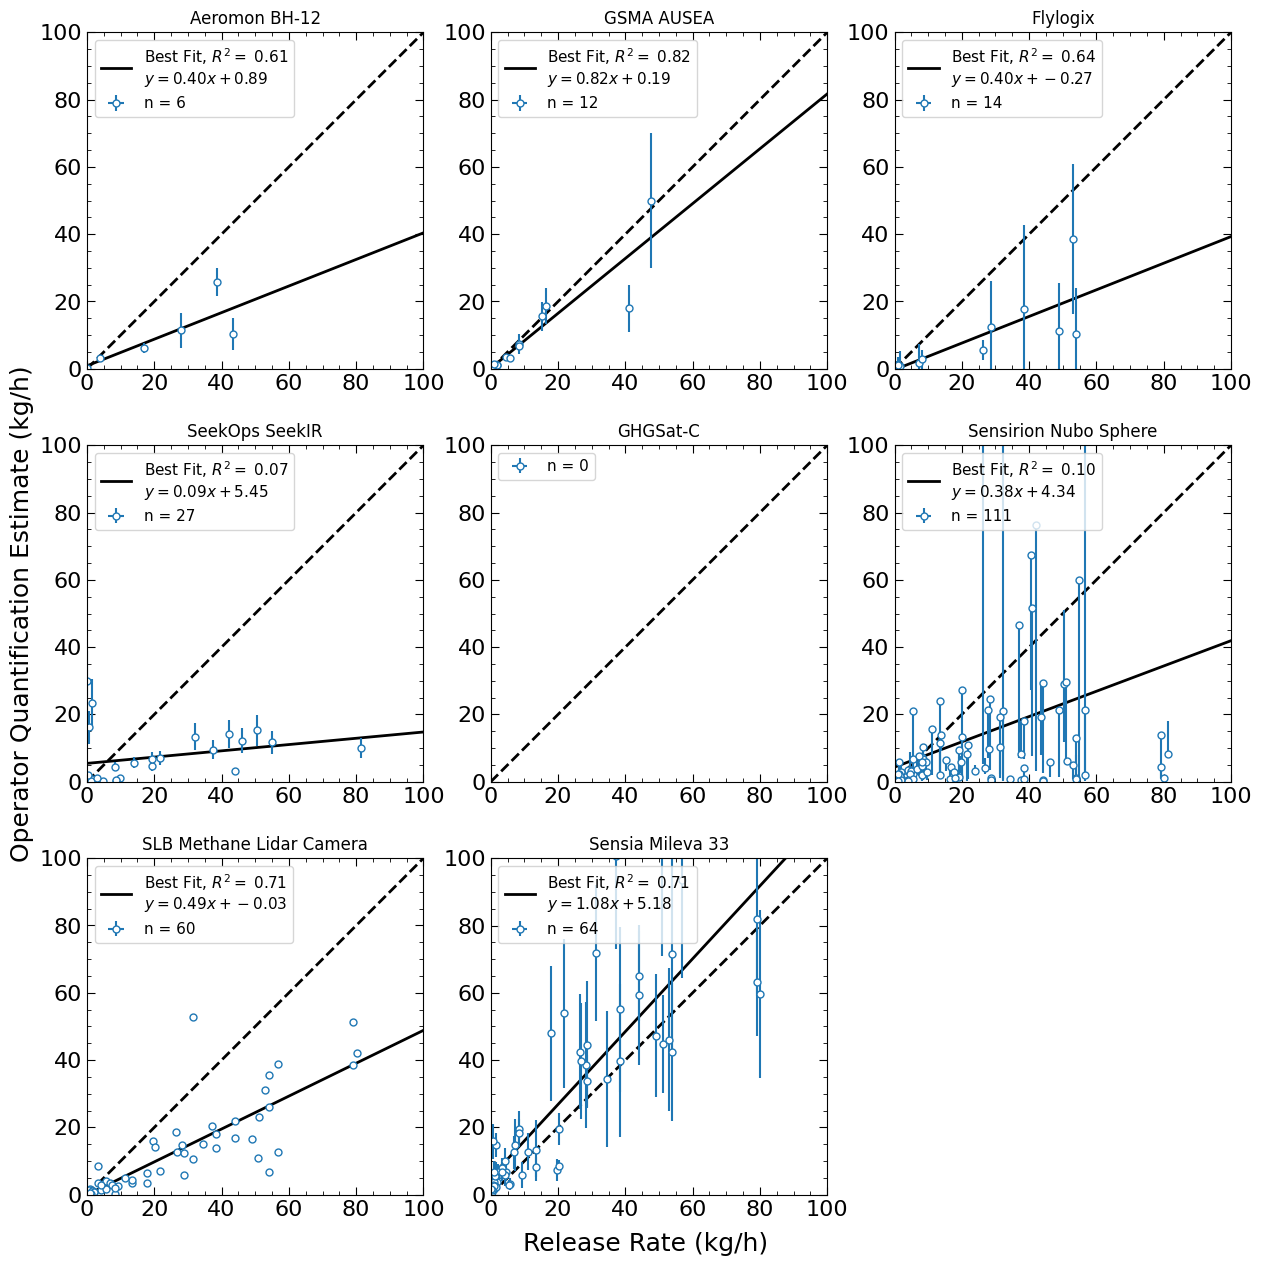

In [3]:
from plot_methods import make_parity_plot, get_parity_data

fig, ax = plt.subplots(3, 3, figsize=[13, 13])
ax = ax.flatten()

for (k, op) in enumerate(COMMERCIAL_OPERATOR_LIST):
    [data, desc] = get_parity_data(op)
    make_parity_plot(data, desc, ax=ax[k], plot_lim=[0, 100])
    ax[k].set_xlabel('')
    ax[k].set_ylabel('')

txt_y_label = fig.text(0.02, 0.5, 'Operator Quantification Estimate (kg/h)', ha='center', va='center', fontsize=18, rotation=90)
txt_x_label = fig.text(0.5, 0.015, 'Release Rate (kg/h)', ha='center', va='center', fontsize=18)


plt.subplots_adjust(left=0.07,
                        bottom=0.05,
                        right=0.95,
                        top=0.95)

ax[8].axis('off')

plt.savefig('report/plots/commercial_teams/parity_commercial_ops_below_100kgh.png')

## Wind analysis

/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


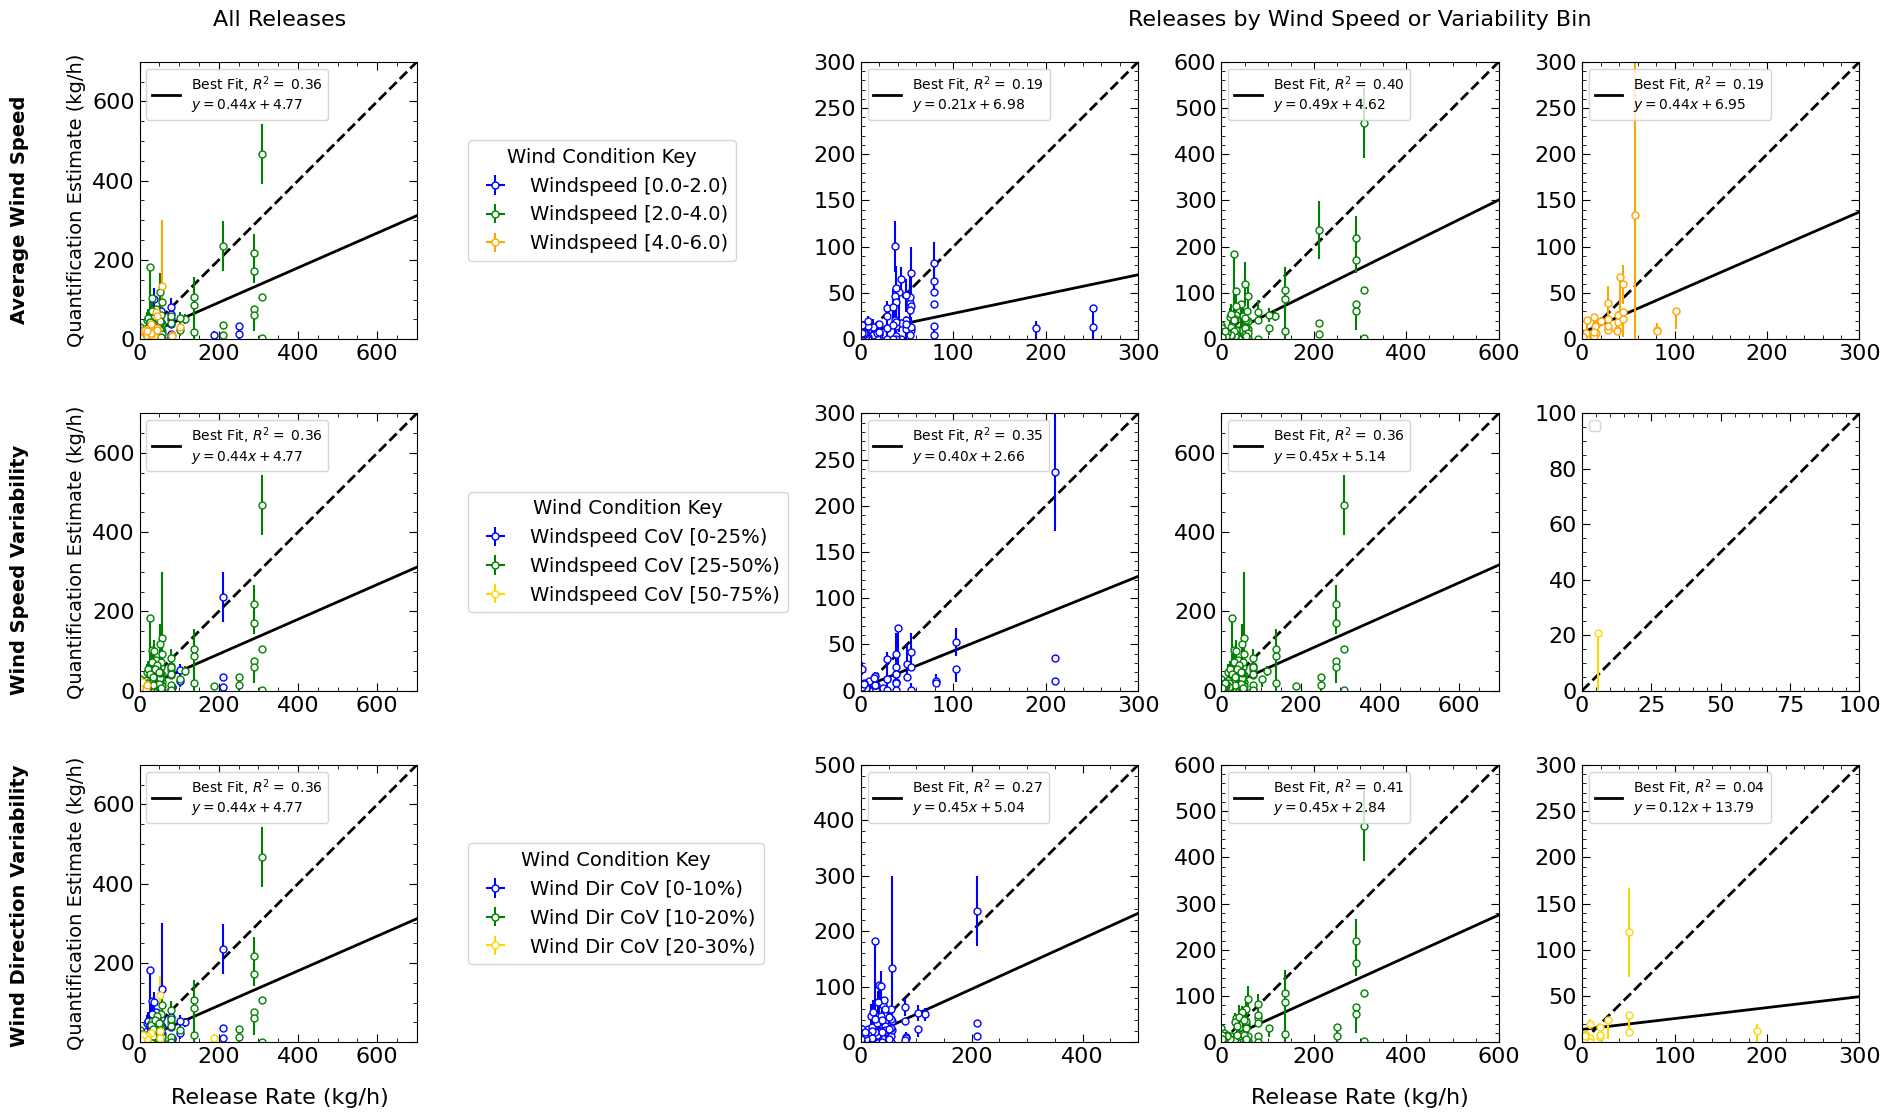

In [5]:
from plot_methods import make_parity_plot, get_parity_data, remove_wind_label, WINDSPEED_BIN_COLOR_MAP
import matplotlib.pyplot as plt

all_windspeed_bins = list(WINDSPEED_BIN_COLOR_MAP.keys())[:-1]
total_num_bins = len(all_windspeed_bins)

op = 'commercial'
fig, ax = plt.subplots(3, 5, figsize=[20, 12], sharex=False, sharey=False,
                       gridspec_kw={'wspace': 0.3, 'hspace': 0.2})

[data, desc] = get_parity_data(op, wind_analysis=True)

# --- ROW 1: WIND SPEED ---
k = 0    
windspeed_bins = data.windspeed_bin.unique().sort_values()

make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_avg')
ax[k, 0].set_title('')
ax[k, 0].set_ylabel('Quantification Estimate (kg/h)')
ax[k, 0].set_xlabel('')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].legend([handles[0]], [labels[0]])

for i, bin in enumerate(windspeed_bins[:3]):
    bin_data = data[data.windspeed_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i+2], wind_analysis='speed_avg')
    ax[k, i+2].set_title('')
    ax[k, i+2].set_xlabel('') 
    ax[k, i+2].set_ylabel('')  
    ax[k, i+2] = remove_wind_label(ax[k, i+2])

# legend in column 1
ax[k, 1].set_xticks([])
ax[k, 1].set_yticks([])
for spine in ax[k, 1].spines.values():
    spine.set_visible(False)
ax[k, 1].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 2: WIND SPEED VARIABILITY ---
k = 1
wind_bins = data.windspeed_variation_coeff_bin.unique().sort_values()

make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_var_coeff')
ax[k, 0].set_title('')
ax[k, 0].set_ylabel('Quantification Estimate (kg/h)')
ax[k, 0].set_xlabel('')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].legend([handles[0]], [labels[0]])

for i, bin in enumerate(wind_bins[:3]):
    bin_data = data[data.windspeed_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i+2], wind_analysis='speed_var_coeff')
    ax[k, i+2].set_title('')   
    ax[k, i+2].set_xlabel('') 
    ax[k, i+2].set_ylabel('')  
    ax[k, i+2] = remove_wind_label(ax[k, i+2])

# legend in column 1
ax[k, 1].set_xticks([])
ax[k, 1].set_yticks([])
for spine in ax[k, 1].spines.values():
    spine.set_visible(False)
ax[k, 1].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 3: WIND DIRECTION VARIABILITY ---
k = 2
dir_bins = data.winddir_variation_coeff_bin.unique().sort_values()

make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='dir_var_coeff')
ax[k, 0].set_title('')
ax[k, 0].set_ylabel('Quantification Estimate (kg/h)')
ax[k, 0].set_xlabel('')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].legend([handles[0]], [labels[0]])

for i, bin in enumerate(dir_bins[:3]):
    bin_data = data[data.winddir_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i+2], wind_analysis='dir_var_coeff')
    ax[k, i+2].set_title('')
    ax[k, i+2].set_xlabel('') 
    ax[k, i+2].set_ylabel('')    
    ax[k, i+2] = remove_wind_label(ax[k, i+2])

# legend in column 1
ax[k, 1].set_xticks([])
ax[k, 1].set_yticks([])
for spine in ax[k, 1].spines.values():
    spine.set_visible(False)
ax[k, 1].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# Layout & Labels
fig.subplots_adjust(left=0.12, right=0.98, top=0.93, bottom=0.1)

# Row labels
fig.text(0.06, 0.8, 'Average Wind Speed', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)
fig.text(0.06, 0.5, 'Wind Speed Variability', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)
fig.text(0.06, 0.22, 'Wind Direction Variability', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)

# Column titles
fig.text(0.19, 0.95, 'All Releases', ha='center', va='bottom', fontsize=16)
fig.text(0.73, 0.95, 'Releases by Wind Speed or Variability Bin', ha='center', va='bottom', fontsize=16)

# ax[0, 0].set_title('All Releases')
# ax[0, 2].set_title('Releases by Wind Speed or Variability Bin')

# X axis label
fig.text(0.19, 0.06, 'Release Rate (kg/h)', va='center', ha='center', fontsize=16)
fig.text(0.73, 0.06, 'Release Rate (kg/h)', va='center', ha='center', fontsize=16)

# Save the figure
plt.savefig('report/plots/commercial_teams/parity_wind_analysis_commercial_ops_windspeed_bins.png')


/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


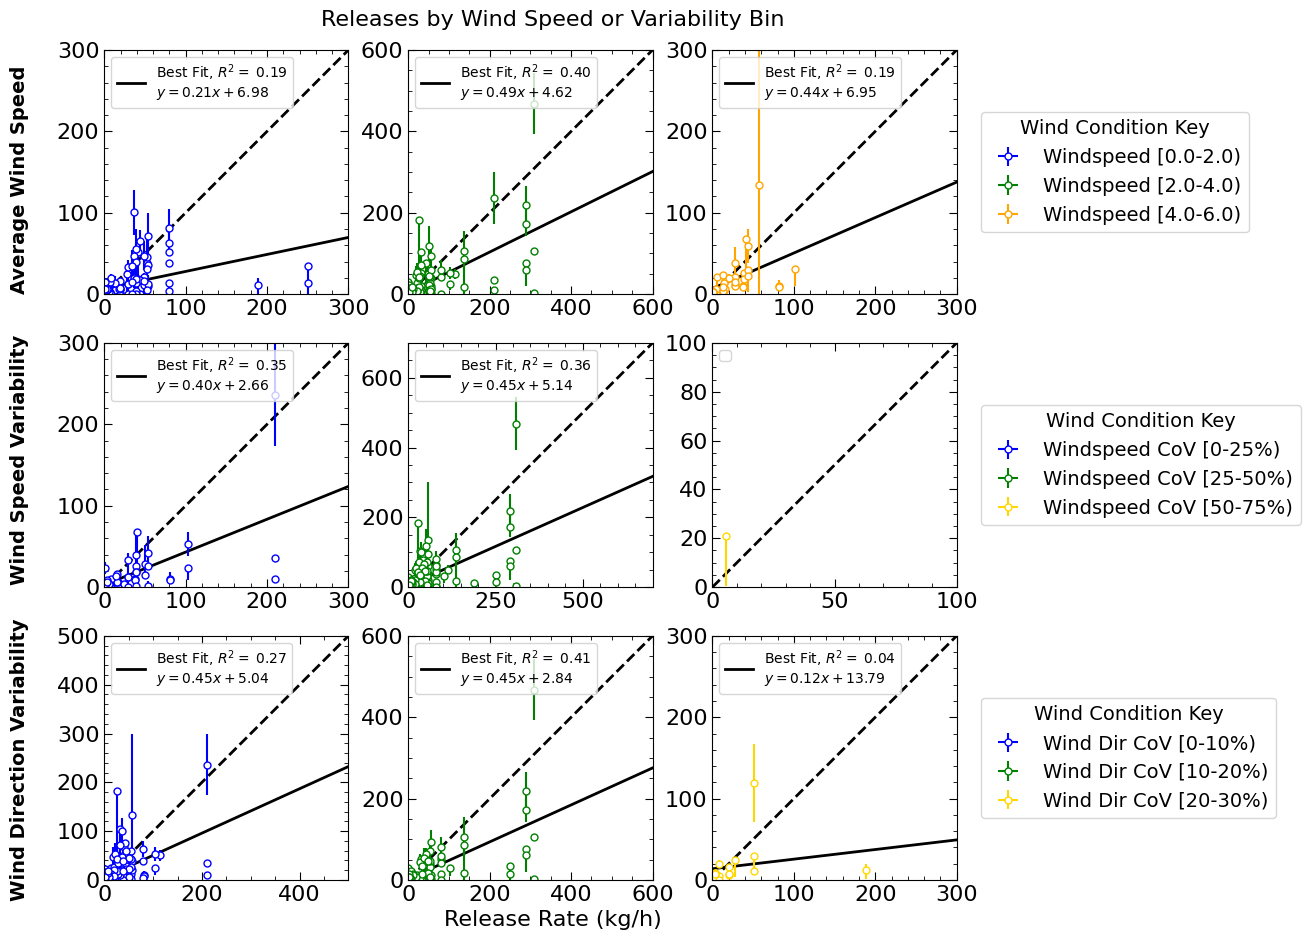

In [3]:
from plot_methods import make_parity_plot, get_parity_data, remove_wind_label, WINDSPEED_BIN_COLOR_MAP
import matplotlib.pyplot as plt

all_windspeed_bins = list(WINDSPEED_BIN_COLOR_MAP.keys())[:-1]
total_num_bins = len(all_windspeed_bins)

op = 'commercial'
fig, ax = plt.subplots(3, 4, figsize=[13, 10], sharex=False, sharey=False,
                       gridspec_kw={'wspace': 0.18, 'hspace': 0.2})

[data, desc] = get_parity_data(op, wind_analysis=True)

# --- ROW 1: WIND SPEED ---
k = 0    
windspeed_bins = data.windspeed_bin.unique().sort_values()

# legend in row 1 
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_avg')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(windspeed_bins[:3]):
    bin_data = data[data.windspeed_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='speed_avg')
    ax[k, i].set_title('')
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')  
    ax[k, i] = remove_wind_label(ax[k, i])

ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 2: WIND SPEED VARIABILITY ---
k = 1
wind_bins = data.windspeed_variation_coeff_bin.unique().sort_values()

# legend in row 2
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_var_coeff')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(wind_bins[:3]):
    bin_data = data[data.windspeed_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='speed_var_coeff')
    ax[k, i].set_title('')   
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')  
    ax[k, i] = remove_wind_label(ax[k, i])

# legend in column 1
ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 3: WIND DIRECTION VARIABILITY ---
k = 2
dir_bins = data.winddir_variation_coeff_bin.unique().sort_values()
# legend in row 2
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='dir_var_coeff')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(dir_bins[:3]):
    bin_data = data[data.winddir_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='dir_var_coeff')
    ax[k, i].set_title('')
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')    
    ax[k, i] = remove_wind_label(ax[k, i])

# legend in column 1
ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# Layout & Labels
fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.1)

# Row labels
fig.text(0.02, 0.8, 'Average Wind Speed', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)
fig.text(0.02, 0.52, 'Wind Speed Variability', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)
fig.text(0.02, 0.22, 'Wind Direction Variability', va='center', ha='center', fontsize=14, fontweight='bold', rotation=90)

# Column titles
fig.text(0.43, 0.95, 'Releases by Wind Speed or Variability Bin', ha='center', va='bottom', fontsize=16)


# X axis label
fig.text(0.43, 0.06, 'Release Rate (kg/h)', va='center', ha='center', fontsize=16)

# Save the figure
plt.savefig('report/plots/commercial_teams/parity_wind_analysis_commercial_ops_windspeed_bins_v2.png')


/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Users/audreymcmanemin/Desktop/RESEARCH/TADI_controlled_release_2024_code/plot_methods.py:207: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_error_upper.iloc[:] = 0
/Users/audreymcmanemin/Desktop/RESEARCH/TADI_controlled_release_2024_code/plot_methods.py:210: SettingWithCopyWarning: 
A value 

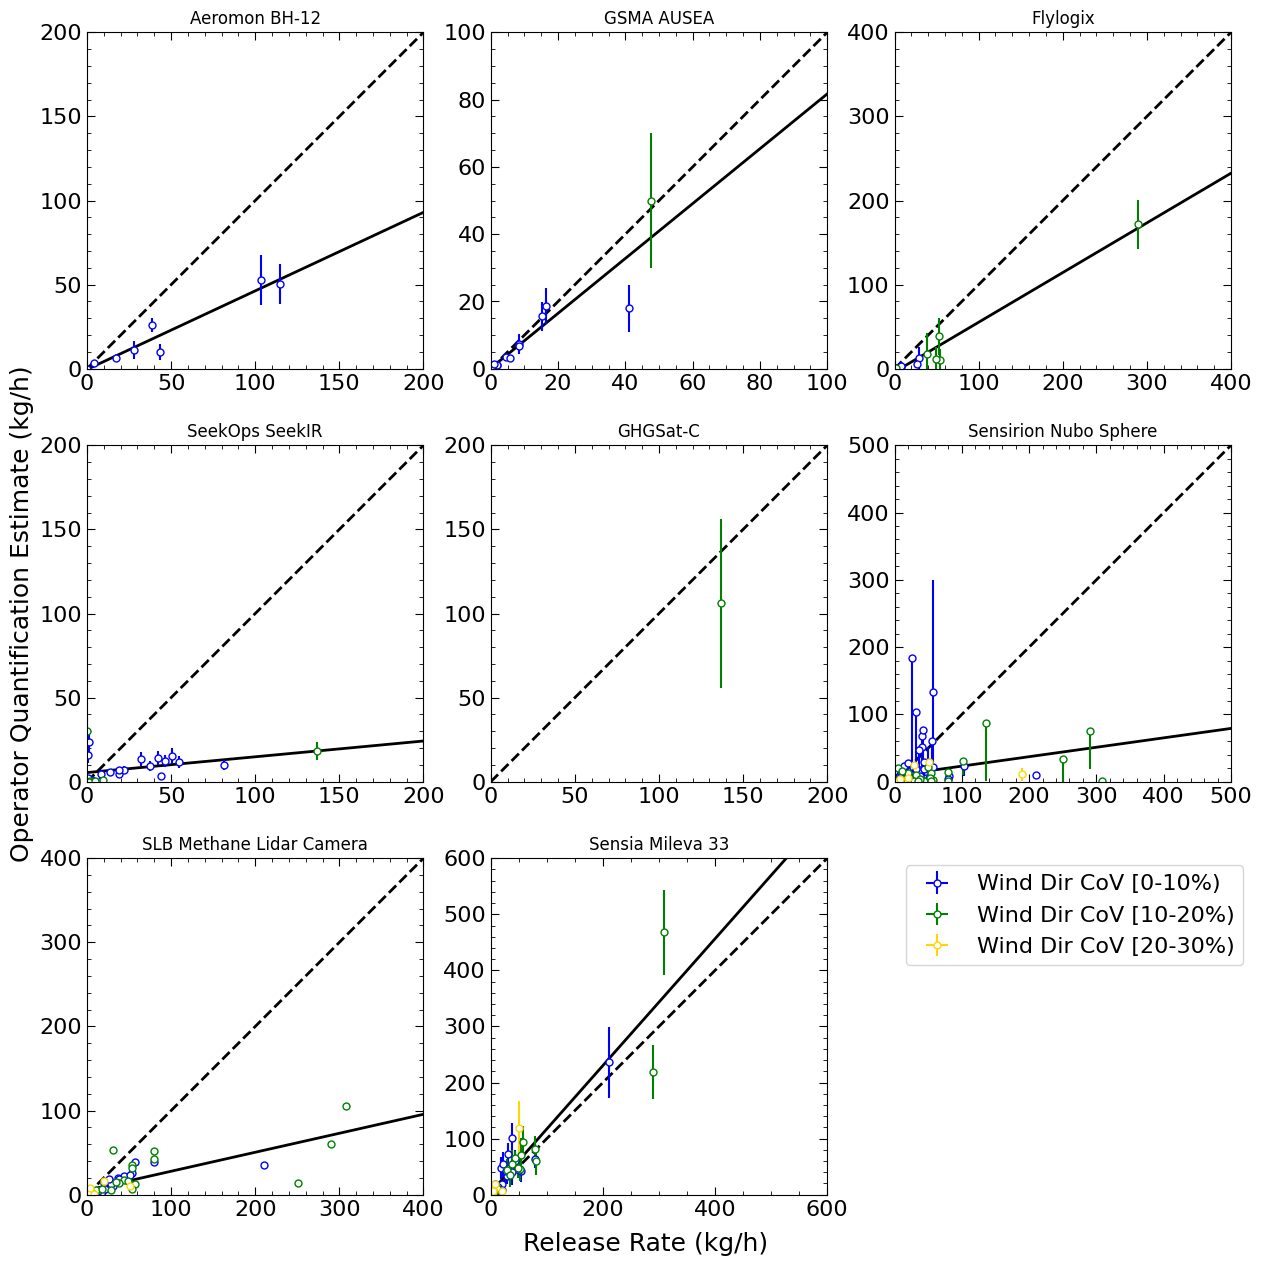

In [ ]:
# wind speed for all operators 
fig, ax = plt.subplots(3, 3, figsize=[13, 13])
ax = ax.flatten()

for (k, op) in enumerate(COMMERCIAL_OPERATOR_LIST):
    [data, desc] = get_parity_data(op, wind_analysis=True)
    make_parity_plot(data, desc, ax=ax[k], wind_analysis='dir_var_coeff')
    ax[k].legend().set_visible(False)
    ax[k].set_xlabel('')
    ax[k].set_ylabel('')

txt_y_label = fig.text(0.02, 0.5, 'Operator Quantification Estimate (kg/h)', ha='center', va='center', fontsize=18, rotation=90)
txt_x_label = fig.text(0.5, 0.015, 'Release Rate (kg/h)', ha='center', va='center', fontsize=18)

plt.subplots_adjust(left=0.07,
                        bottom=0.05,
                        right=0.95,
                        top=0.95)

handles, labels = ax[5].get_legend_handles_labels()
ax[8].set_xticks([])
ax[8].set_yticks([])
for spine in ax[8].spines.values():
    spine.set_visible(False)
ax[8].legend(handles[1:], labels[1:], loc='upper left', fontsize=16)

# plt.suptitle('Technology Type Parity Plots by Average Windspeed (20m) of Releases', fontsize=20)
# plt.tight_layout(rect=[0, 0, 1, 0.98])
# plt.savefig('report/plots/commercial_teams/parity_winddir_cov_commercial_ops.png')


## Release Categorization

In [ ]:
import pandas as pd
from methods import load_release_summary, COMMERCIAL_OPERATOR_LIST

# OPERATOR_LIST = ['Sensirion']
for op in COMMERCIAL_OPERATOR_LIST:
    df = load_release_summary(op)
    df_qc = df[df['stanford_kept']]
    print(
        f"{op}: \n"
        f"    Total releases: {df.shape[0]} \n"
        f"    Total number of releases measured = {df[df['strict_qc_kept']].shape[0]} \n"
        f"    QC Passing Releases = {df_qc.shape[0]} \n"
        f"    True positives: {df_qc.true_positive.sum()} ({(100 * df_qc.true_positive.sum() / df_qc.shape[0]):.0f}%) \n"
        f"    False positives: {df_qc.false_positive.sum()} ({(100 * df_qc.false_positive.sum() / df_qc.shape[0]):.0f}%) \n"
        f"    True negatives: {df_qc.true_negative.sum()} ({(100 * df_qc.true_negative.sum() / df_qc.shape[0]):.0f}%)\n"
        f"    False negatives: {df_qc.false_negative.sum()} ({(100 * df_qc.false_negative.sum() / df_qc.shape[0]):.0f}%)\n"
        f"    Max release detected = {max(df_qc[df_qc['operator_detected'] & df_qc['non_zero_release']]['release_rate_kgh'])} kg/h \n"
        f"    Min release detected = {min(df_qc[df_qc['operator_detected'] & df_qc['non_zero_release']]['release_rate_kgh'])} kg/h \n"
        # f"    Max release measured = {max(df[df['strict_qc_kept']]['release_rate_kgh'])} kg/h \n"
        f"    Min release measured = {min(df[df['strict_qc_kept']]['release_rate_kgh'])} kg/h \n"
        # f"    Max release passing Stanford QC = {max(df_qc['release_rate_kgh'])} kg/h \n"
        # f"    Min release passing Stanford QC = {min(df_qc['release_rate_kgh'])} kg/h \n"
    )



### distribution of releases

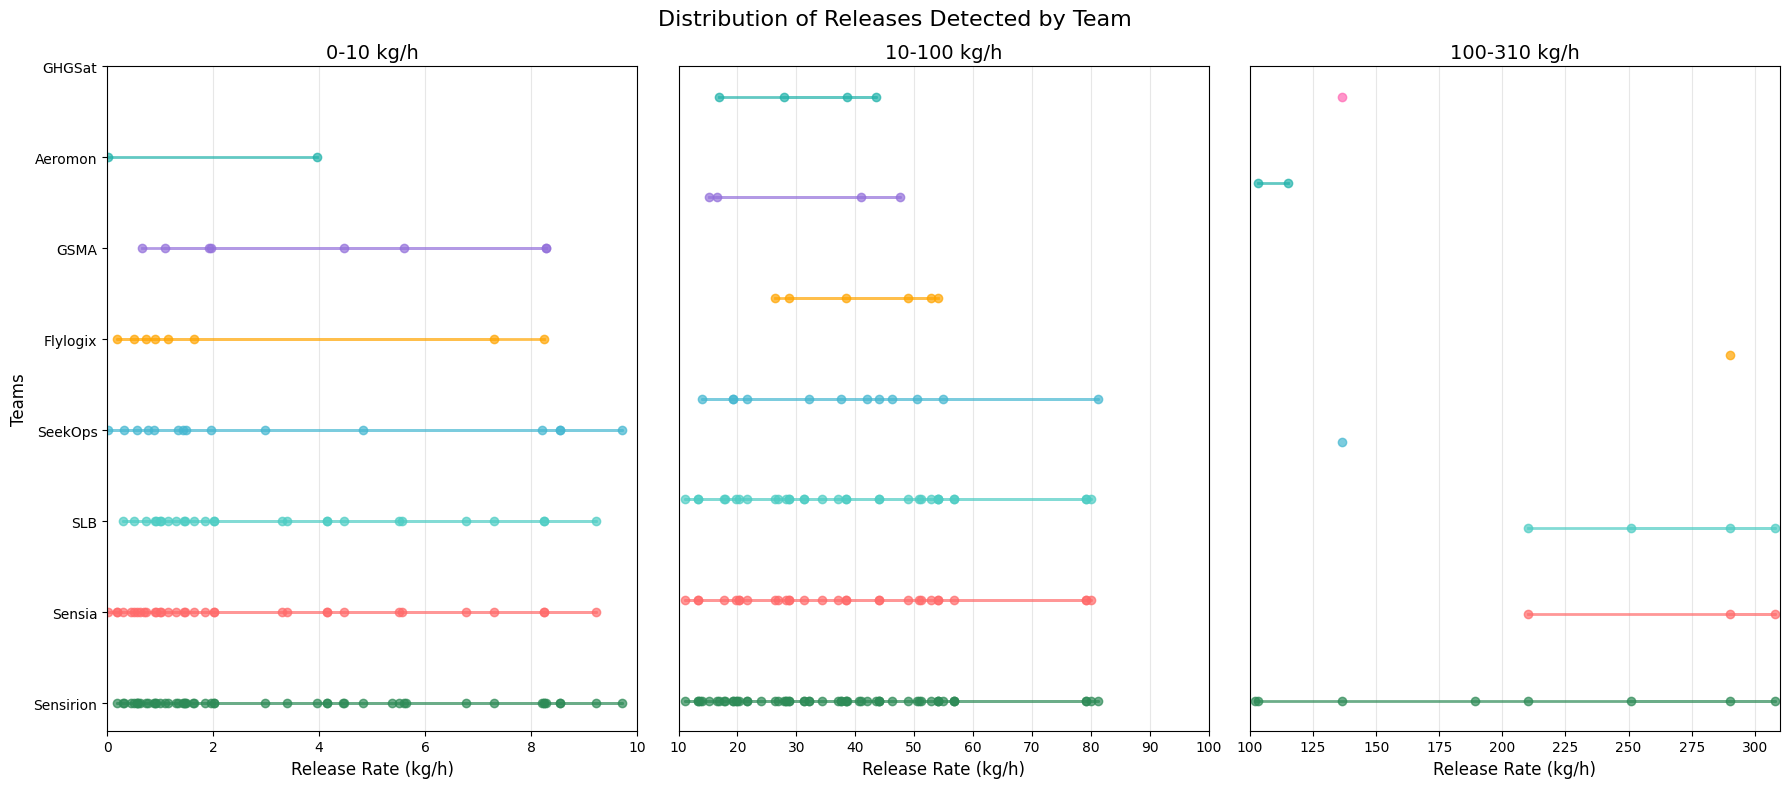

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from methods import load_release_summary, COMMERCIAL_OPERATOR_LIST

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Colors for different categories
colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA500', '#9370DB', '#20B2AA', '#FF69B4']

# Process data for each team
team_data = []
for operator in COMMERCIAL_OPERATOR_LIST:
    df = load_release_summary(operator)
    df_qc = df[df['stanford_kept']]  # Only QC passing releases
    
    if len(df_qc) > 0:
        # Get release rates for detected releases
        detected_releases = df_qc[df_qc['operator_detected'] & df_qc['non_zero_release']]['release_rate_kgh']
        
        if len(detected_releases) > 0:
            team_data.append({
                'team': operator,
                'release_rates': detected_releases.values,
                'count': len(detected_releases)
            })

# Sort teams by number of detections
team_data.sort(key=lambda x: x['count'], reverse=True)

# Define x-axis ranges
ranges = [(0, 10), (10, 100), (100, 310)]
range_labels = ['0-10 kg/h', '10-100 kg/h', '100-310 kg/h']

# Create subplots for each range
for subplot_idx, (x_min, x_max) in enumerate(ranges):
    ax = axes[subplot_idx]
    
    # Plot each team's data as a horizontal line
    for i, data in enumerate(team_data):
        # Filter releases within this range
        releases_in_range = data['release_rates'][(data['release_rates'] >= x_min) & (data['release_rates'] < x_max)]
        
        if len(releases_in_range) > 0:
            y_position = i
            
            # Plot line connecting all points
            ax.plot(releases_in_range, [y_position] * len(releases_in_range), 
                    'o-', color=colors[i % len(colors)], 
                    markersize=6, linewidth=2, alpha=0.7,
                    label=f"{data['team']} ({len(releases_in_range)} detections)")

    # Customize the subplot
    ax.set_ylabel('Teams' if subplot_idx == 0 else '', fontsize=12)
    ax.set_xlabel('Release Rate (kg/h)', fontsize=12)
    ax.set_title(f'{range_labels[subplot_idx]}', fontsize=14)
    
    # Set x-axis limits
    ax.set_xlim(x_min, x_max)
    
    # Set y-axis labels only for the first subplot
    if subplot_idx == 0:
        ax.set_yticks(range(len(team_data)))
        ax.set_yticklabels([data['team'] for data in team_data])
    else:
        ax.set_yticks([])
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='x')
    

# Add overall title
fig.suptitle('Distribution of Releases Detected by Team', fontsize=16, y=0.98)
# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.savefig('report/plots/commercial_teams/commercial_teams_detected_releases_distributions.png')
plt.show()